In [0]:
import pandas as pd


###  Load and preview the dataset
In this step, we load the dataset from the Spark table into a pandas DataFrame, then display the first few rows of the dataset.

In [0]:
# 1.1
df=spark.table("brightcoffee.sales.data").toPandas()
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,2026-05-30 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,2026-05-30 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,2026-05-30 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,2026-05-30 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,2026-05-30 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


### Checking the row & columns
 In this step, we examine the number of rows and columns it contains. 


In [0]:
# 1.2
df.shape

(149116, 11)

### View column names
In this step, we display all column names in the dataset 

In [0]:
# 1.2
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='object')

### Check data types
In this step, we inspect the data types of each column in the dataset.

In [0]:
# 1.2
df.dtypes

transaction_id               int64
transaction_date            object
transaction_time    datetime64[ns]
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object

### Check for missing values
In this step, we check for missing values in each column of the dataset.

In [0]:
# 1.3
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

### Generate summary statistics for numerical data
In this step, we generate descriptive statistics for the numerical columns in the dataset.

In [0]:
# 1.4
df.describe()

,transaction_id,transaction_time,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2026-05-30 12:14:15.815794688,1.438276,5.342063,47.918607,3.382219
min,1.000000,2026-05-30 06:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2026-05-30 09:05:10.500000,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2026-05-30 11:15:28,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2026-05-30 15:25:57,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2026-05-30 20:59:32,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


### Generate summary statistics for categorical data
In this step, we generate descriptive statistics for categorical (object-type) columns in the dataset.

In [0]:
# 1.4
df.describe(include='object')

,transaction_date,store_location,product_category,product_type,product_detail
count,149116,149116,149116,149116,149116
unique,181,3,9,29,80
top,2023-06-19,Hell's Kitchen,Coffee,Brewed Chai tea,Chocolate Croissant
freq,1343,50735,58416,17183,3076


### Analyze product category distribution
In this step, we are counting how many times values in `product_category` appear.

In [0]:
# 1.5
print(df['product_category'].value_counts())

product_category
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: count, dtype: int64


### Analyze store distribution
In this step, we count how many times each store appears in the dataset.

In [0]:
# 1.5
df['store_location'].value_counts()

store_location
Hell's Kitchen     50735
Astoria            50599
Lower Manhattan    47782
Name: count, dtype: int64

# TASK 2

### Create a revenue column
In this step, we calculate the total revenue for each transaction by multiplying the unit price by the quantity purchased. 

In [0]:
# 2.1
df['Revenue']=df['unit_price']*df['transaction_qty']
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue
0,1,2023-01-01,2026-05-30 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2023-01-01,2026-05-30 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2023-01-01,2026-05-30 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2023-01-01,2026-05-30 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2023-01-01,2026-05-30 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


### Convert transaction date to datetime format
In this step, we convert the `transaction_date` column into a proper datetime format. 

In [0]:

df['transaction_date']=pd.to_datetime(df['transaction_date'])
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue
0,1,2023-01-01,2026-05-30 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2023-01-01,2026-05-30 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2023-01-01,2026-05-30 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2023-01-01,2026-05-30 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2023-01-01,2026-05-30 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


### Extract hour and month 
In this step, we extract `Hour` and the `Month` from the `transaction_date` column. 

In [0]:
# 2.2
Hour=df['Hour']=df['transaction_time'].dt.hour
Month=df['Month']=df['transaction_date'].dt.month
df.head()


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,Hour,Month
0,1,2023-01-01,2026-05-30 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,7,1
1,2,2023-01-01,2026-05-30 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,1
2,3,2023-01-01,2026-05-30 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,7,1
3,4,2023-01-01,2026-05-30 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,7,1
4,5,2023-01-01,2026-05-30 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,7,1


### Visualize distribution of unit price
In this step, we create a histogram of the `unit_price` column

<Axes: >

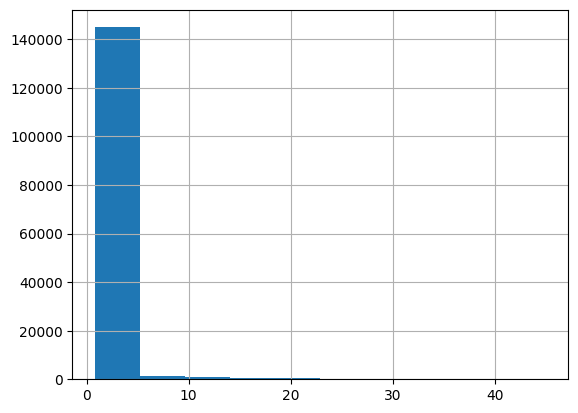

In [0]:
# 2.3
df['unit_price'].hist()

### Calculate total revenue per store location
In this step, we group the dataset by `store_location` and calculate the total `Revenue` for each store. We then visualize the results using a bar graph.

<Axes: xlabel='store_location'>

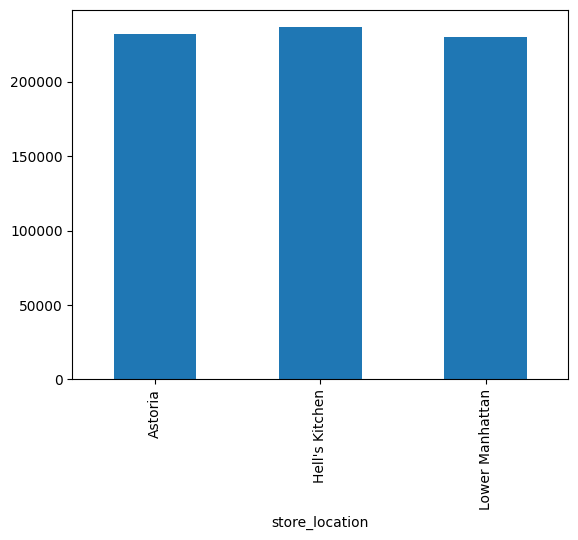

In [0]:
# 2.4
store_rev=df.groupby("store_location")['Revenue'].sum()
store_rev.plot.bar()

### Analyze transaction patterns by hour
In this step, we group the dataset by `Hour` and count the number of transactions (`transaction_qty`) for each hour. We then plot the results as a line chart.

<Axes: xlabel='Hour'>

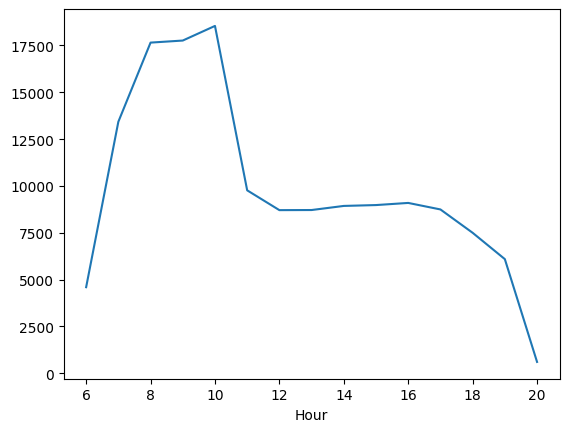

In [0]:
# 2.5
df.groupby('Hour')['transaction_qty'].count().plot(kind='line')
#df.plot.line()

#### 2.5
####When is the shop busiest?
the store is the busiest between the 9th to the 11th hour 

# TASK 3

In [0]:
import seaborn as sns

### Analyze correlation between numerical variables
In this step, we are generating correlation matrix for `unit_price`, `Revenue`, and `transaction_qty` using Spearman correlation. We then visualize the relationships using a heatmap.

<Axes: >

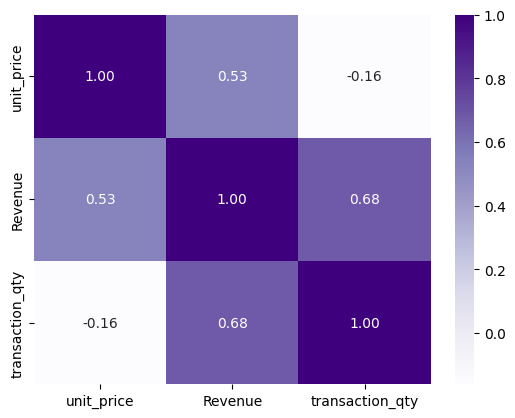

In [0]:
# 3.1
sns.heatmap(df[['unit_price','Revenue','transaction_qty']].corr(numeric_only=True, method= 'spearman'), annot=True,fmt='.2f',cmap='Purples')

### Create a pivot table for revenue analysis
In this step, we create a pivot table to summarize total `Revenue` by `store_location`  and `product_category`. 

In [0]:
# 3.2
pivot_table=pd.pivot_table(df, 
               values='Revenue',
               index='store_location',
               columns='product_category',
               aggfunc='sum')
pivot_table

product_category,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
store_location,,,,,,,,,
Astoria,26599.75,5457.0,89744.30,10219.20,26335.25,1764.8,3194.00,1089.71,67839.90
Hell's Kitchen,27386.95,1942.0,91222.65,18635.10,23586.25,2876.8,4461.35,1698.77,64701.30
Lower Manhattan,28328.94,6208.0,88985.50,11230.95,22494.50,3767.2,3558.25,1619.16,63864.75


### Visualize revenue across categories using a pivot table
In this step, we visualize the pivot table using a bar chart to compare revenue across different product categories and store locations.

<Axes: xlabel='store_location'>

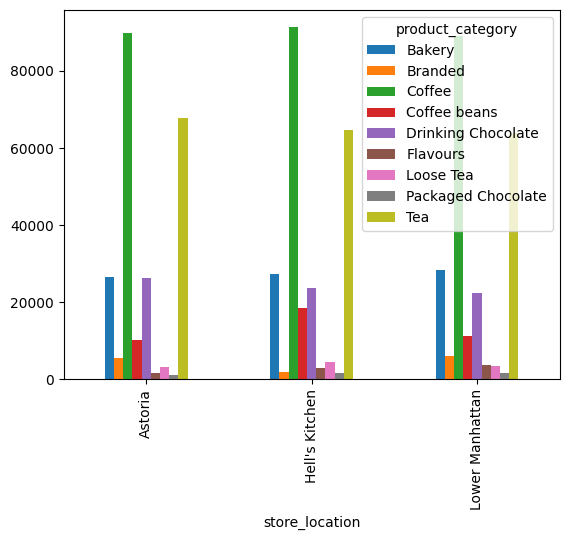

In [0]:
# 3.3
pivot_table.plot.bar()

### Rank store locations by total revenue
In this step, we group the dataset by `store_location` and calculate the total `Revenue` for each store. We then sort the results in descending order to identify which store locations generate the highest revenue.

In [0]:
df.groupby("store_location")['Revenue'].sum().sort_values(ascending=False)

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: Revenue, dtype: float64

#### 3.4
##### Which store earns the most? Which product category drives the most revenue overall?

Hell's kitchen earns slightly more from the other stores and coffee is mostly bought in all store,which drives most revenue.



# TASK 4

### Calculate and rank revenue by product category
In this step, we group the dataset by `product_category` and calculate the total `Revenue` for each category. We then sort the results in descending order to identify the top-performing product categories. 

In [0]:
prod_cat_rev=df.groupby("product_category")['Revenue'].sum().sort_values(ascending=False).reset_index()
prod_cat_rev

,product_category,Revenue
0,Coffee,269952.45
1,Tea,196405.95
2,Bakery,82315.64
3,Drinking Chocolate,72416.00
4,Coffee beans,40085.25
5,Branded,13607.00
6,Loose Tea,11213.60
7,Flavours,8408.80
8,Packaged Chocolate,4407.64


In [0]:
import matplotlib.pyplot as plt
import plotly.express as px

### Creating a bar graph with Seaborn
In this step, we create a bar plot using Seaborn to visualize total revenue for each product category. 

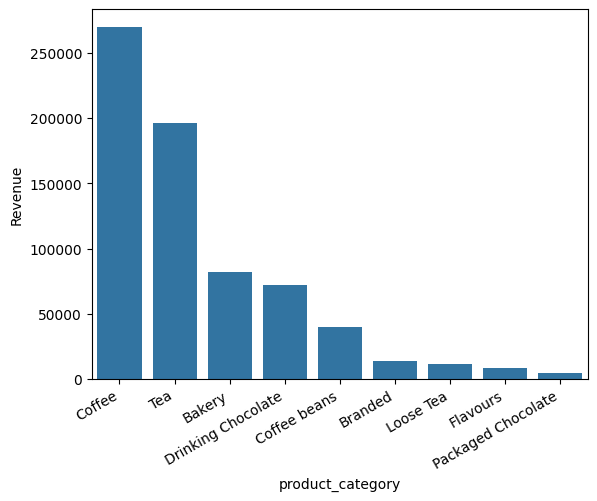

In [0]:
# 4.1
sns.barplot(data=prod_cat_rev,x='product_category',y='Revenue')
plt.xticks(rotation=30,ha='right')
plt.show()



### Creating a bar chart with Matplotlib
In this step, we use Matplotlib to create a customized bar chart showing total revenue per product category. We adjust the figure size, add labels for clarity, rotate x-axis ticks for readability, and apply styling to improve the overall presentation of the visualization.

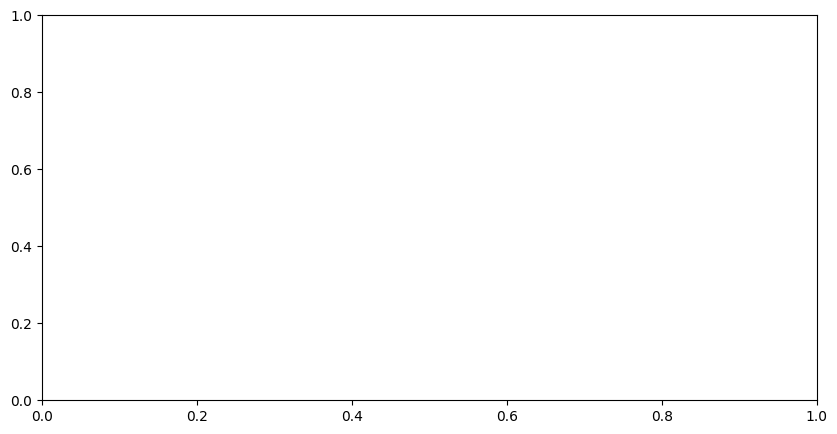

---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
File <command-8053039582141174>, line 4
      1 # 4.1
      3 fig,ax=plt.subplots(figsize=(10,5))
----> 4 ax.bar(prod_cat_rev.index,prod_cat_rev.values,color='purple',edgecolor='white')
      6 ax.tick_params(axis='x',rotation=30)
      7 ax.set_xlabel("Product Category")

File /databricks/python/lib/python3.12/site-packages/matplotlib/__init__.py:1521, in _preprocess_data.<locals>.inner(ax, data, *args, **kwargs)
   1518 @functools.wraps(func)
   1519 def inner(ax, *args, data=None, **kwargs):
   1520     if data is None:
-> 1521         return func(
   1522             ax,
   1523             *map(cbook.sanitize_sequence, args),
   1524             **{k: cbook.sanitize_sequence(v) for k, v in kwargs.items()})
   1526     bound = new_sig.bind(ax, *args, **kwargs)
   1527     auto_label = (bound.arguments.get(label_namer)
   1528       

In [0]:
# 4.1

fig,ax=plt.subplots(figsize=(10,5))
ax.bar(prod_cat_rev.index,prod_cat_rev.values,color='purple',edgecolor='white')

ax.tick_params(axis='x',rotation=30)
ax.set_xlabel("Product Category")
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.show()

In [0]:
!pip install plotly

### Creating a bar graph using Plotly
In this step, we use Plotly Express to create an interactive bar chart showing total revenue per product category. 

In [0]:
# 4.1
fg = px.bar(prod_cat_rev, x='product_category', y='Revenue',
            color='Revenue',
            #changing the bar colour to shades of purple
            #color_continuous_scale='Purples'
          
            )
fg.show()

#### 4.1
Written response (4–6 sentences): Which library required the most code? Which had the best default
output? In what real-world scenario would you choose plotly over seaborn?

matplotlib requires most code to generate a bar,needs a code for the x-axis and y-axis titles/labels,tilting the values of the x-avis to be properly displayed and code of what you what to display.

plotly had the best default output.

i would choose plotly because in just a one line of code you get the x-axis and y-axis labels.The x-axis values displayed clearly without being stacking on top of each other.




# TASK 5

### Business Insights

1.Hell's Kitchen is the top-performing store, while coffee contributes the highest share of revenue at 39%, significantly outperforming other product categories.

2.The bar graph of Revenue by store location and product category.The revenue by store location clearly show how store are performing in terms of revenue.

3.The business should ensure coffee inventory remains fully stocked during peak hours and introduce bundled promotions (for example, coffee paired with a lower-performing product at a discounted price) to increase sales of underperforming items.